In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GroupKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import xgboost as xgb
from sklearn.preprocessing import TargetEncoder 
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
import lime
from IPython.display import display
import lime.lime_tabular
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.base import is_regressor
from sklearn.linear_model import SGDRegressor
from sklearn.svm import LinearSVR
from sklearn.kernel_approximation import RBFSampler

In [2]:
# 1. Cargar y preparar datos
df = pd.read_csv("california_accidents_cleaned.csv", parse_dates=['year_week'])
df[['start_date_str', 'end_date_str']] = df['year_week'].str.split('/', expand=True)
df['start_date'] = pd.to_datetime(df['start_date_str'])
df['year'] = df['start_date'].dt.isocalendar().year
df['week'] = df['start_date'].dt.isocalendar().week
df.drop(['start_date_str', 'end_date_str'], axis=1, inplace=True)

C:\Users\Sara\AppData\Local\Temp\ipykernel_14112\1061881644.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("california_accidents_cleaned.csv", parse_dates=['year_week'])


In [3]:
X = df.drop(['accident_count', 'zone_week_id', 'year_week'], axis=1)
y = df['accident_count']
groups = df['zone_id']
time_series = df['year'] * 100 + df['week']

In [4]:
# Ordenar por fecha (aseguramos orden temporal)
sorted_idx = np.argsort(time_series)
X_sorted = X.iloc[sorted_idx]
y_sorted = y.iloc[sorted_idx]
groups_sorted = groups.iloc[sorted_idx]

In [5]:
# Dividir 75% entrenamiento / 25% test
n_train = int(0.75 * len(X_sorted))
X_train, X_test = X_sorted.iloc[:n_train], X_sorted.iloc[n_train:]
y_train, y_test = y_sorted.iloc[:n_train], y_sorted.iloc[n_train:]
groups_train = groups_sorted.iloc[:n_train]  # <-- groups original

In [6]:
# Preprocesamiento: eliminar NaN y actualizar grupos
X_train = X_train.dropna(subset=["Temperature(F)", "Wind_Speed(mph)", "Humidity(%)"])
y_train = y_train.loc[X_train.index]
groups_train = groups_train.loc[X_train.index]  # <-- ¡Actualizar grupos!

In [7]:
# 2. Preprocesamiento
numerical_features = [
    "Temperature(F)", "Wind_Speed(mph)", "Precipitation(in)", "Humidity(%)",
    "Start_Lat", "Start_Lng"
]
categorical_features = [
    "zone_id"
]
count_features = [
    "Junction", "Railway", "Roundabout", "Station", "Stop", "Traffic_Signal",
    "Temperature(F)_extreme", "Wind_Speed(mph)_extreme", "Precipitation(in)_extreme",
    "Humidity(%)_extreme", "is_night", "is_weekend"
]

In [8]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), 
        ('scaler', StandardScaler())
    ]), ["Temperature(F)", "Wind_Speed(mph)", "Humidity(%)", "Start_Lat", "Start_Lng"]),
    
    # Imputar Precipitation(in) por separado con 0
    ('precipitation', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),  # <-- ¡Nueva!
        ('scaler', StandardScaler())
    ]), ["Precipitation(in)"]),
    
    ('cat', TargetEncoder(target_type='continuous'), ["zone_id"]),
    ('count', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),  
    ]), count_features)
])

In [9]:
pipelines = {
    'knn': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=3, weights='uniform', algorithm='kd_tree'))  # Forzar KD-Tree
    ]),
    'ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=0.1, solver='saga', random_state=42))  # Optimizador saga
    ]),
    'lasso': Pipeline([
        ('preprocessor', preprocessor),
        ('model', SGDRegressor(penalty='l1', alpha=0.1, max_iter=10000, random_state=42))
    ]),
    'random_forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42))
    ]),
    'xgboost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            tree_method='hist',
            predictor='cpu_predictor',
            max_depth=3,
            learning_rate=0.1,
            n_estimators=100
        ))
    ]),
    # Lineal más rápido
    'svr_linear': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearSVR(C=1.0, max_iter=10000, random_state=42))
    ]),
    # Aproximación RBF con Random Fourier Features
    'svr_rbf': Pipeline([
        ('preprocessor', preprocessor),
        ('rbf_sampler', RBFSampler(gamma=1.0, n_components=100, random_state=42)),
        ('model', SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', random_state=42))
    ])
}

In [10]:
param_grids = {
    'knn': {'model__n_neighbors': [3], 'model__weights': ['uniform']},  # KD-Tree se fuerza en el pipeline
    'ridge': {'model__alpha': [0.1]},  # solver='saga' ya se especifica
    'lasso': {'model__alpha': [0.1]},
    'random_forest': {'model__n_estimators': [100], 'model__max_depth': [None]},
    'xgboost': {
        'model__n_estimators': [100], 
        'model__max_depth': [3], 
        'model__learning_rate': [0.1]
    },
    'svr_linear': {'model__C': [1.0]},
    'svr_rbf': {}  # SGDRegressor con RBFSampler no tiene params por ahora
}

In [11]:
# 4. Validación cruzada
tscv = TimeSeriesSplit(n_splits=3)
group_kfold = GroupKFold(n_splits=3)
scorer = make_scorer(root_mean_squared_error, squared=False)

In [12]:
results = []


Optimizando KNN


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__n_neighbors': 3, 'model__weights': 'uniform'}
  - Train RMSE: 6.53, MAE: 3.80, R2: 0.38
  - Test  RMSE: 6.10, MAE: 3.52, R2: 0.42


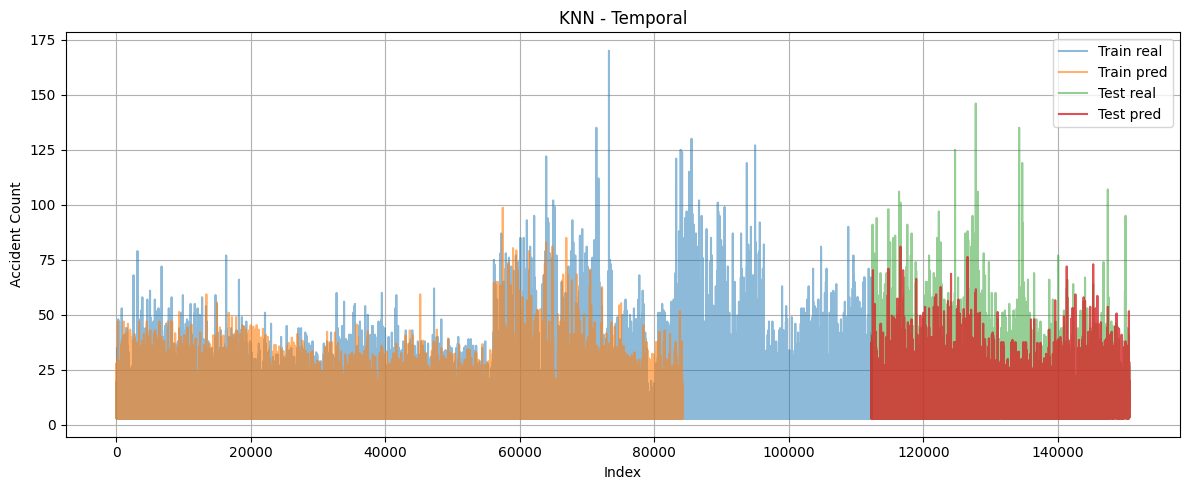

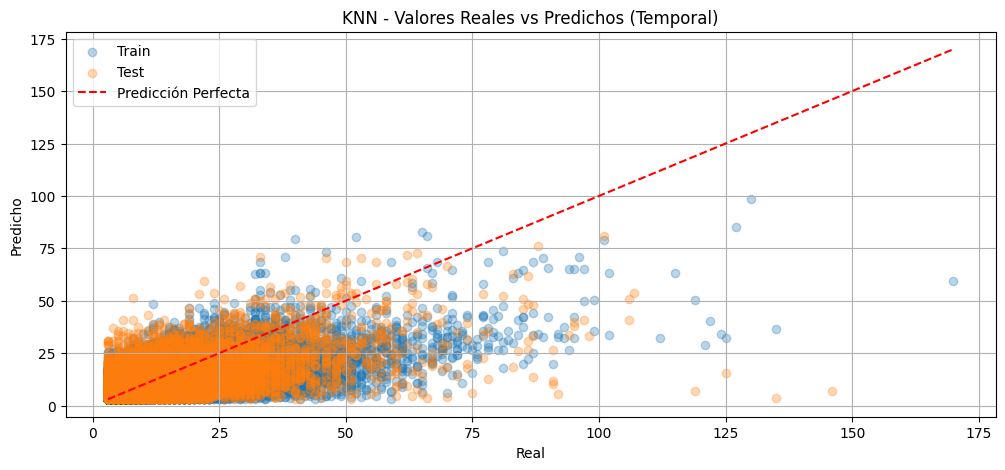

<Figure size 1200x400 with 0 Axes>

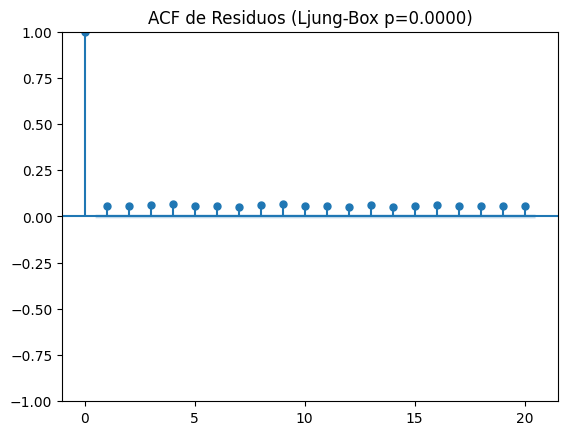

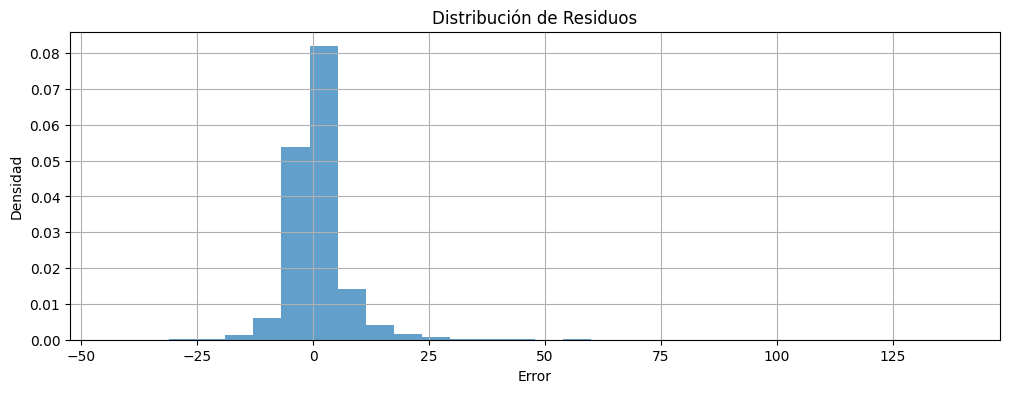

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__n_neighbors': 3, 'model__weights': 'uniform'}
  - Train RMSE: 7.63, MAE: 4.63, R2: 0.04
  - Test  RMSE: 6.06, MAE: 3.50, R2: 0.43


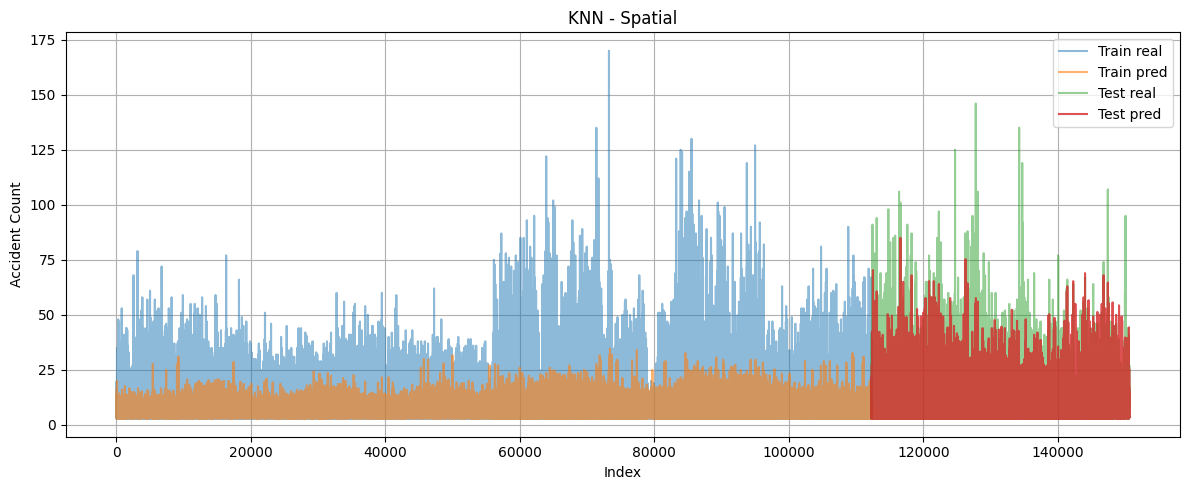

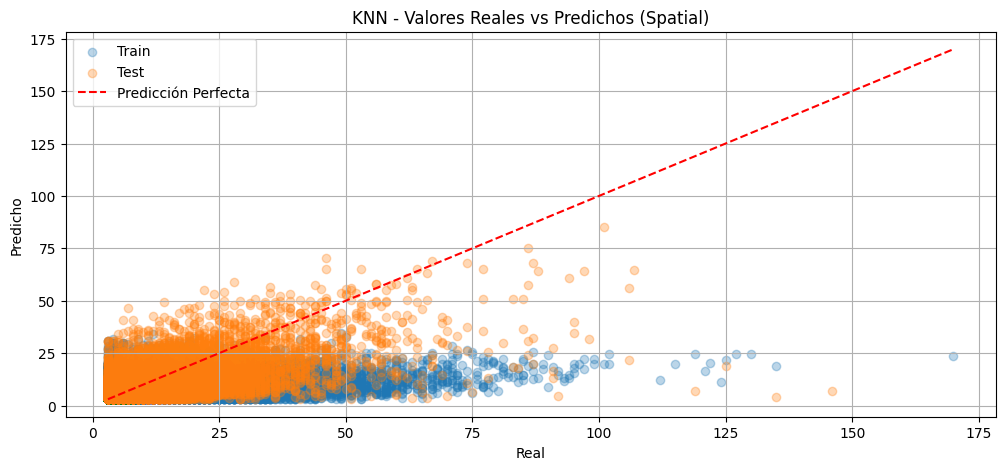

<Figure size 1200x400 with 0 Axes>

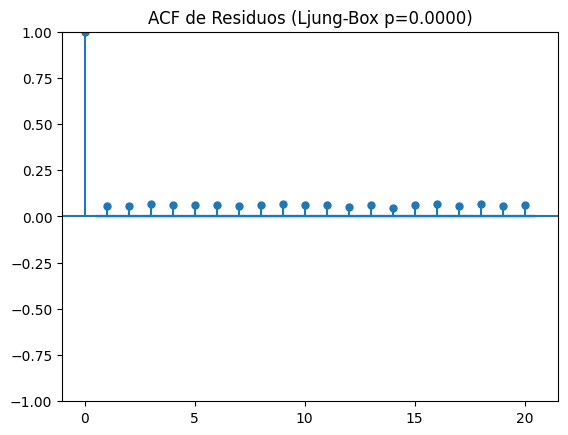

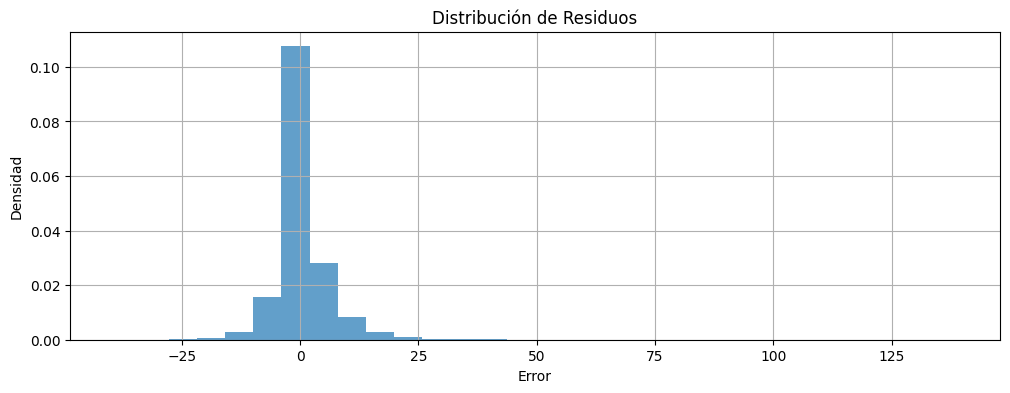


Optimizando RIDGE


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not co


→ Validación: TEMPORAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 3.93, MAE: 2.40, R2: 0.77
  - Test  RMSE: 4.10, MAE: 2.35, R2: 0.74


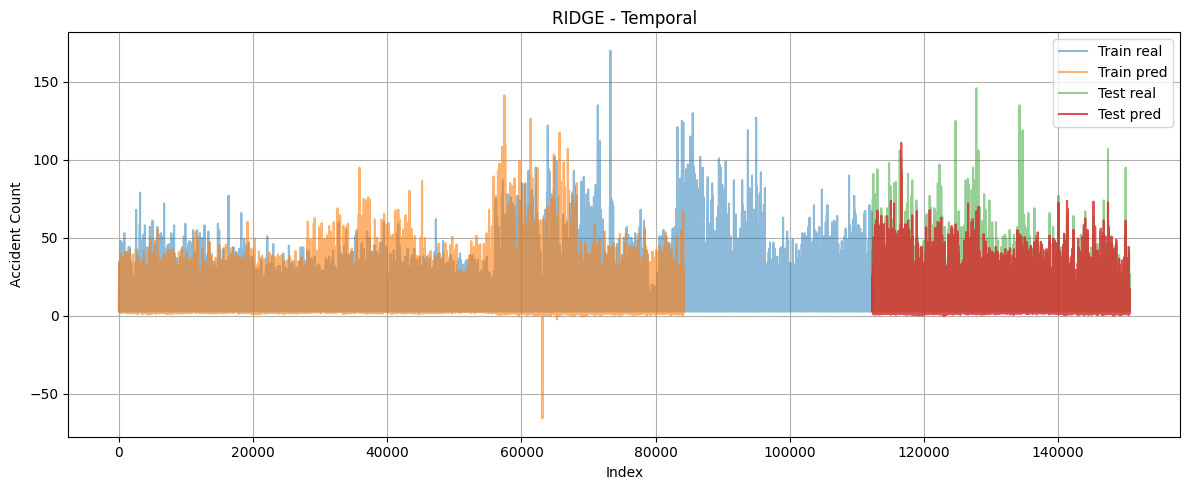

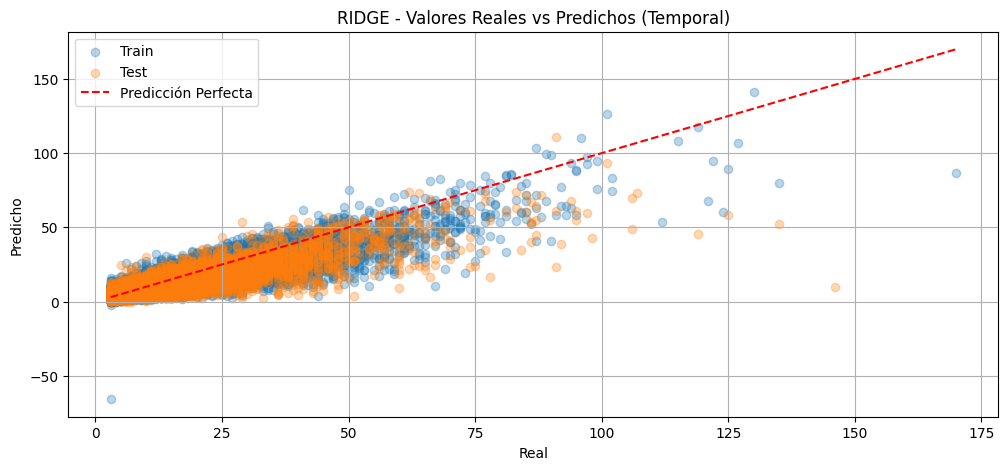

<Figure size 1200x400 with 0 Axes>

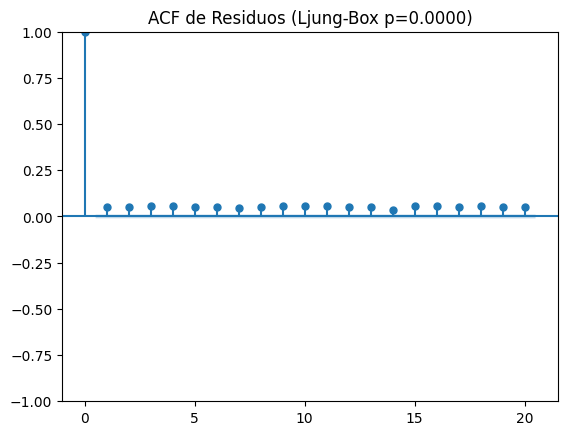

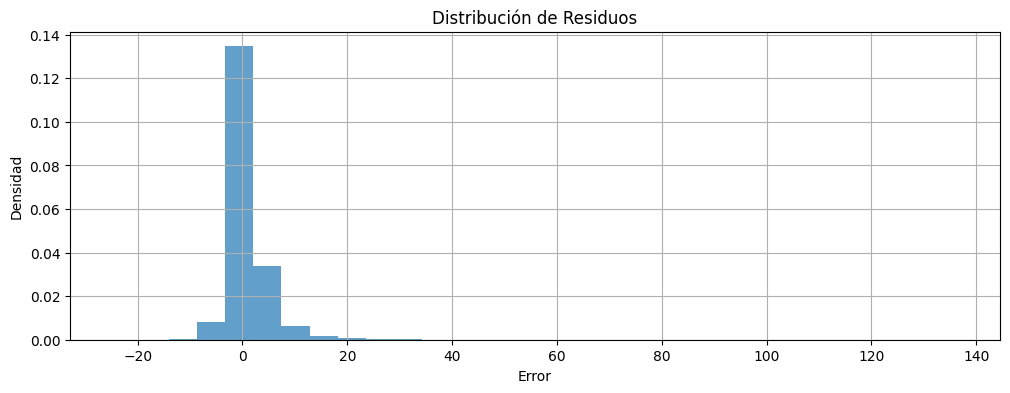

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 4.07, MAE: 2.68, R2: 0.73
  - Test  RMSE: 4.10, MAE: 2.35, R2: 0.74


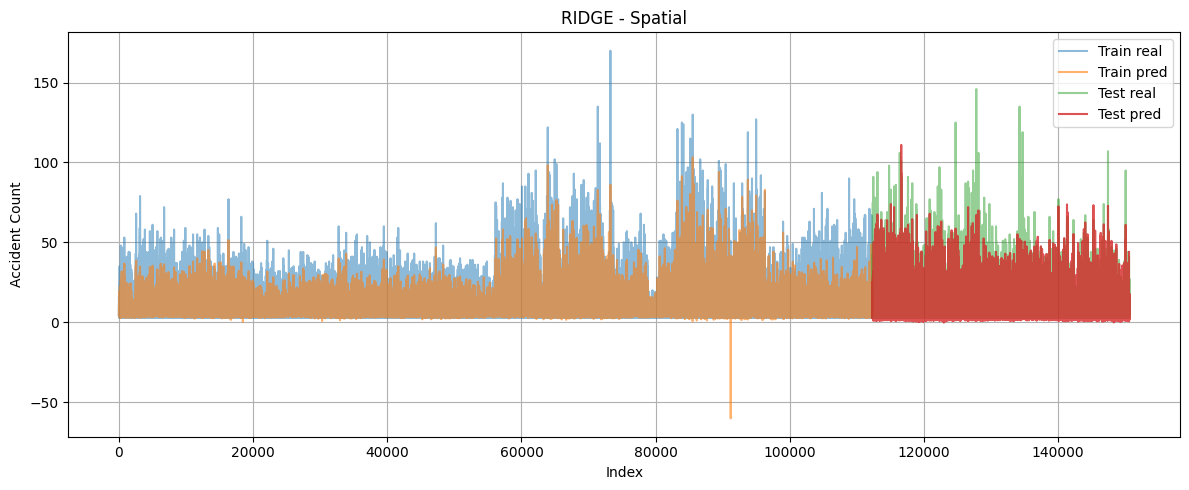

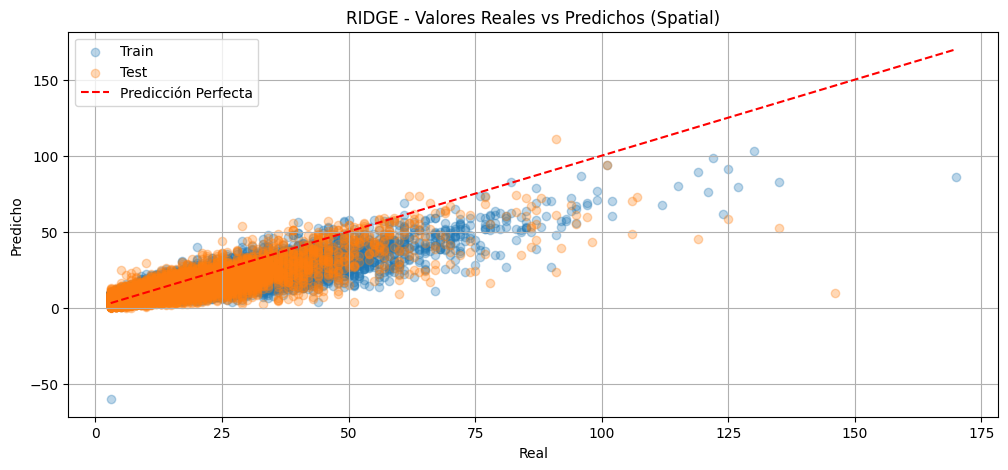

<Figure size 1200x400 with 0 Axes>

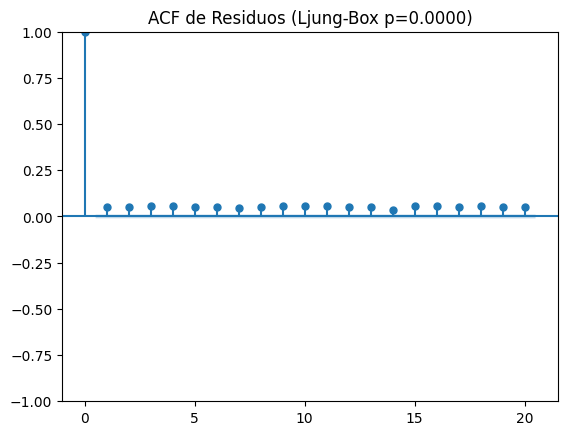

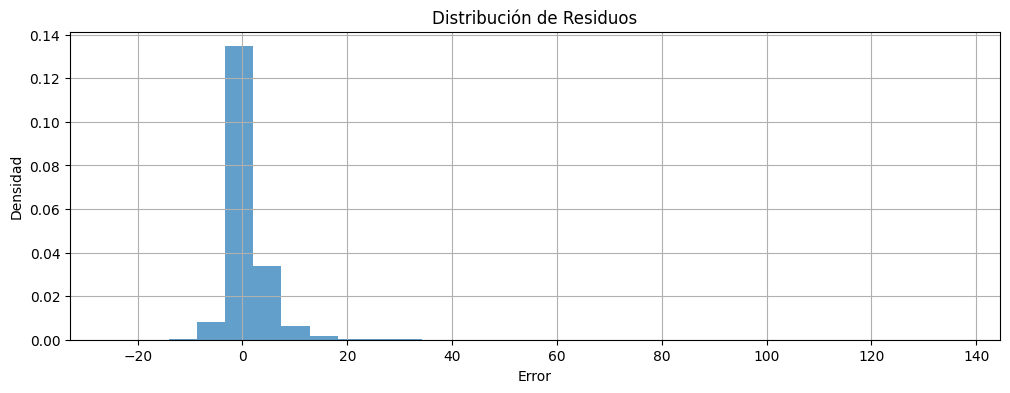


Optimizando LASSO


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 6.50, MAE: 3.69, R2: 0.38
  - Test  RMSE: 5.19, MAE: 2.91, R2: 0.58


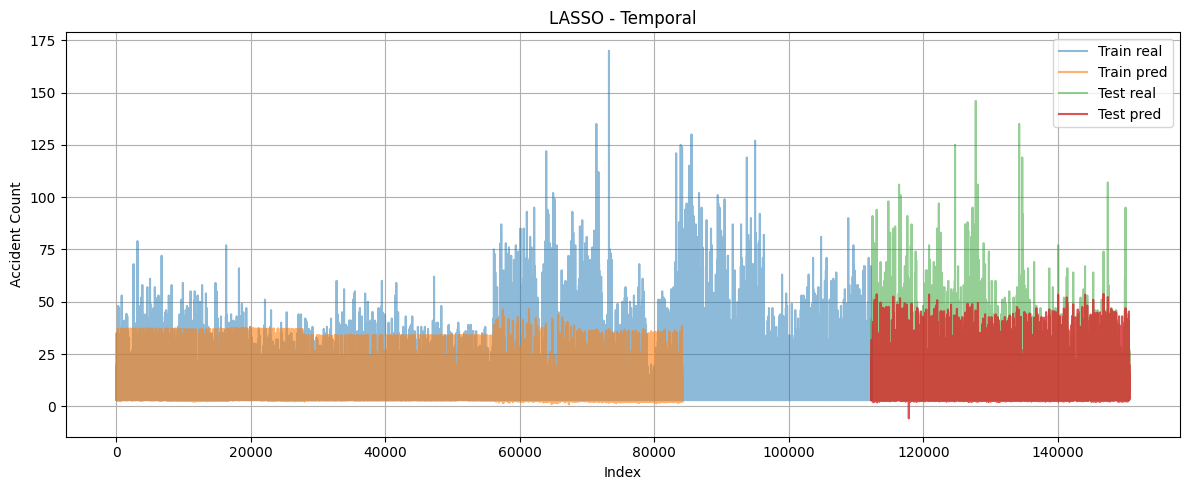

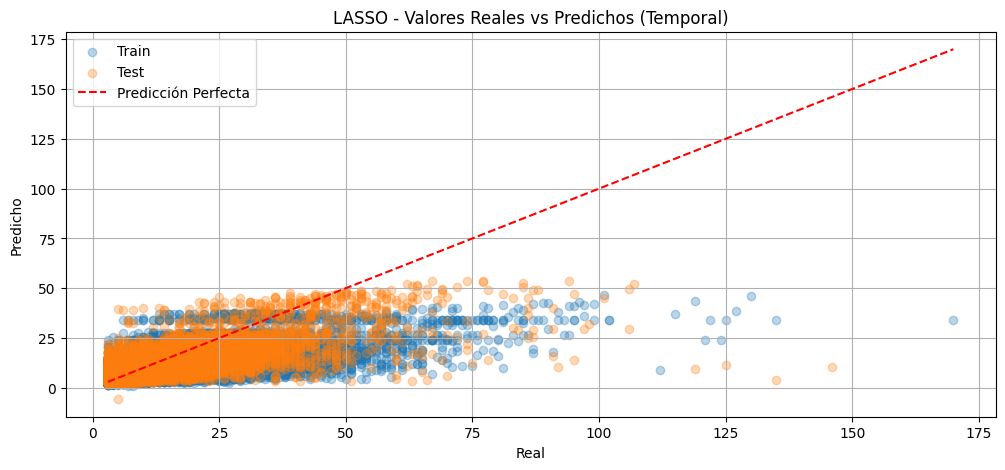

<Figure size 1200x400 with 0 Axes>

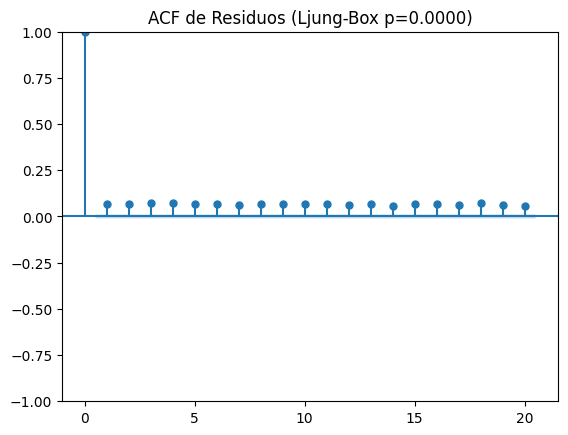

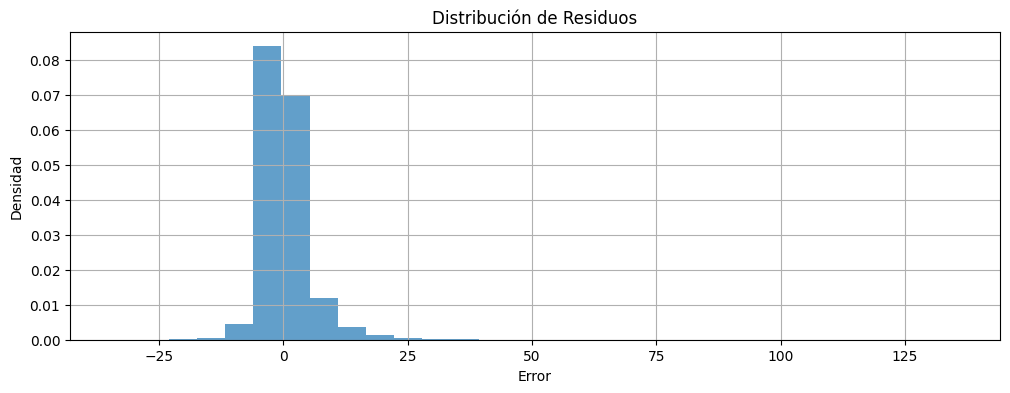

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__alpha': 0.1}
  - Train RMSE: 6.80, MAE: 4.21, R2: 0.24
  - Test  RMSE: 5.19, MAE: 2.91, R2: 0.58


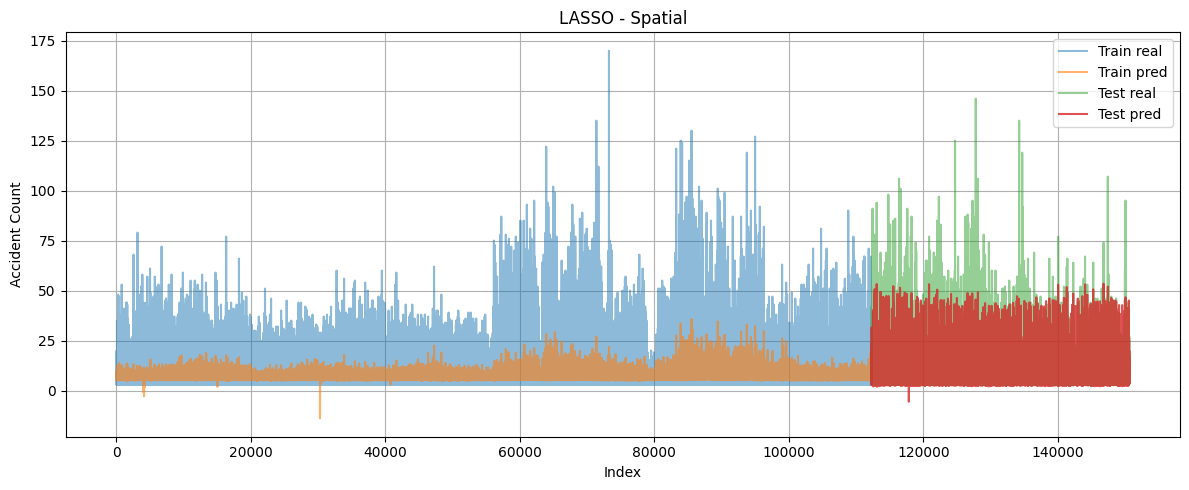

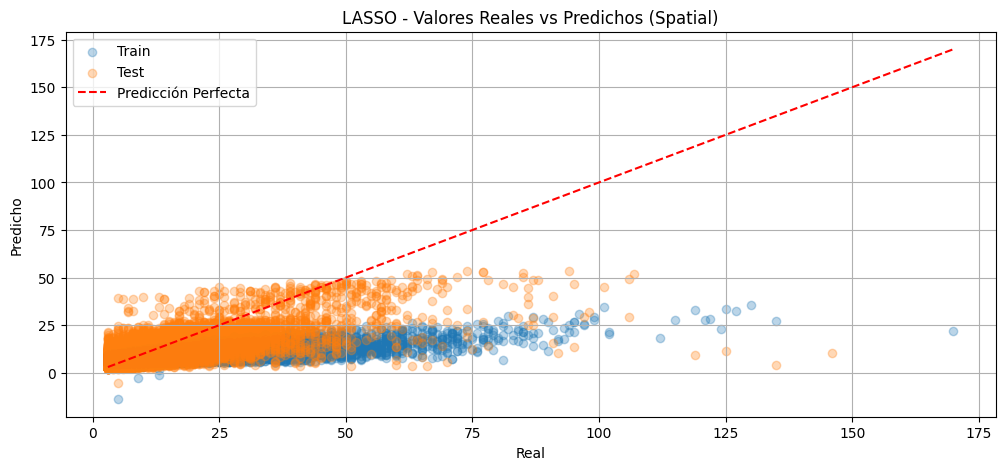

<Figure size 1200x400 with 0 Axes>

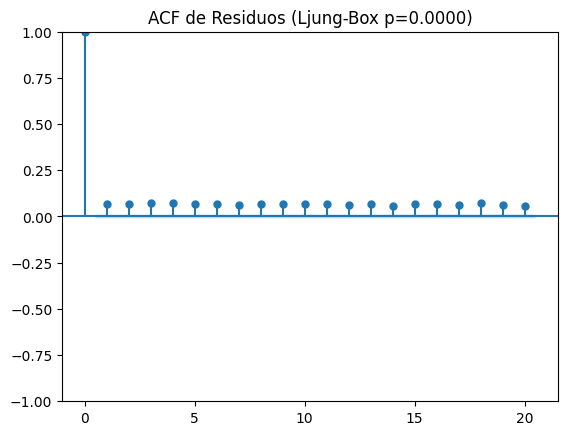

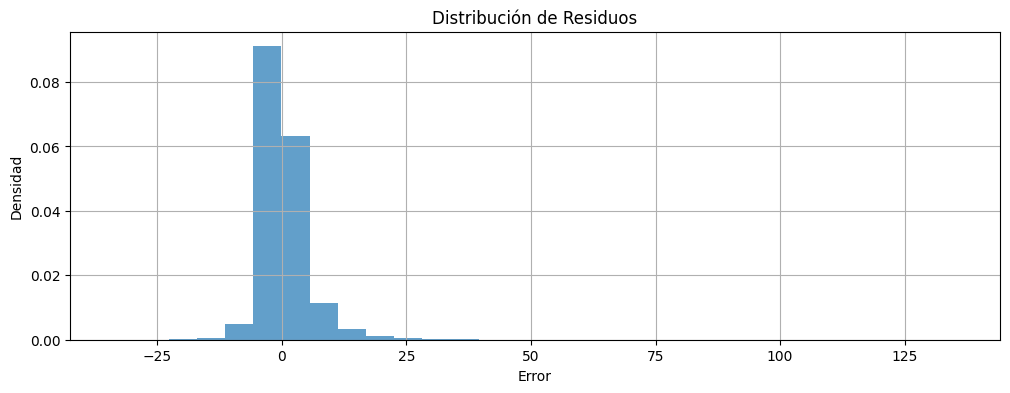


Optimizando RANDOM_FOREST


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(


Error en LIME: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

→ Validación: TEMPORAL
  - Mejores parámetros: {'model__max_depth': None, 'model__n_estimators': 100}
  - Train RMSE: 3.78, MAE: 2.17, R2: 0.79
  - Test  RMSE: 3.90, MAE: 2.08, R2: 0.76


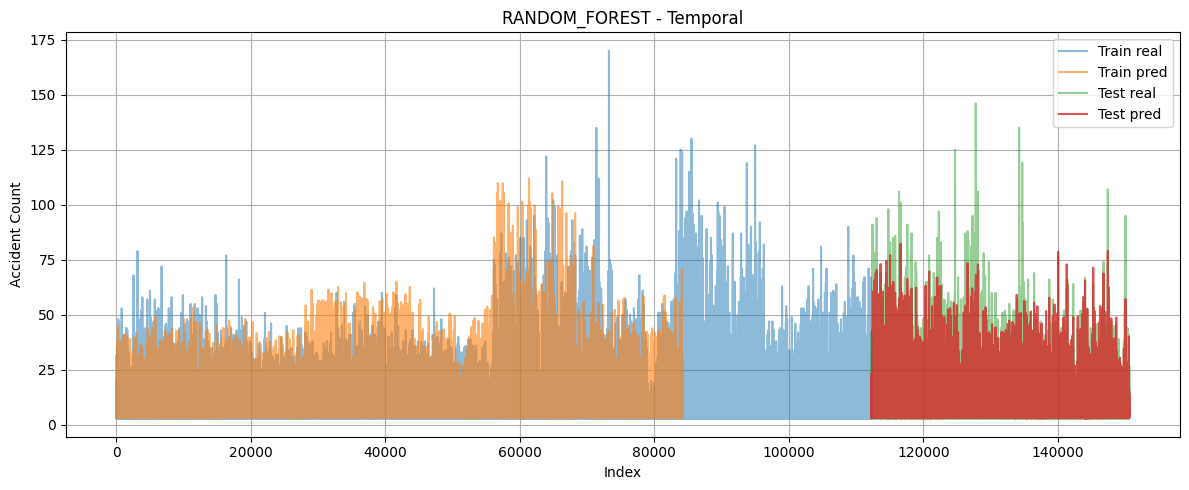

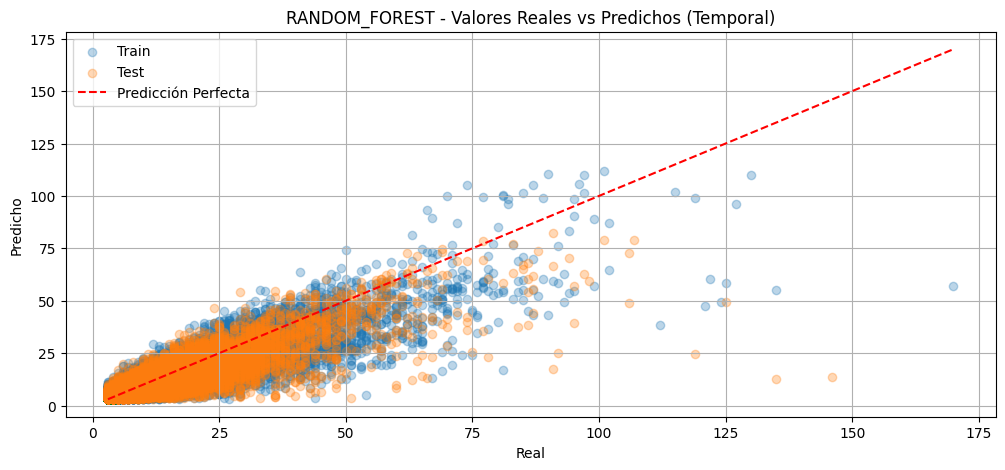

<Figure size 1200x400 with 0 Axes>

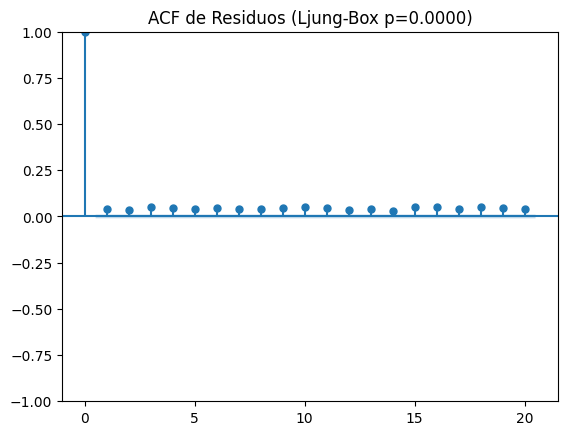

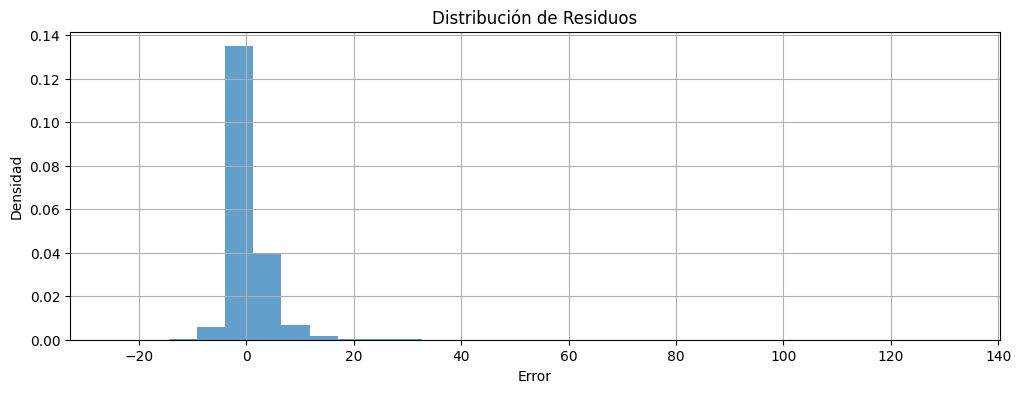

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(


Error en LIME: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

→ Validación: SPATIAL
  - Mejores parámetros: {'model__max_depth': None, 'model__n_estimators': 100}
  - Train RMSE: 3.99, MAE: 2.37, R2: 0.74
  - Test  RMSE: 3.90, MAE: 2.08, R2: 0.76


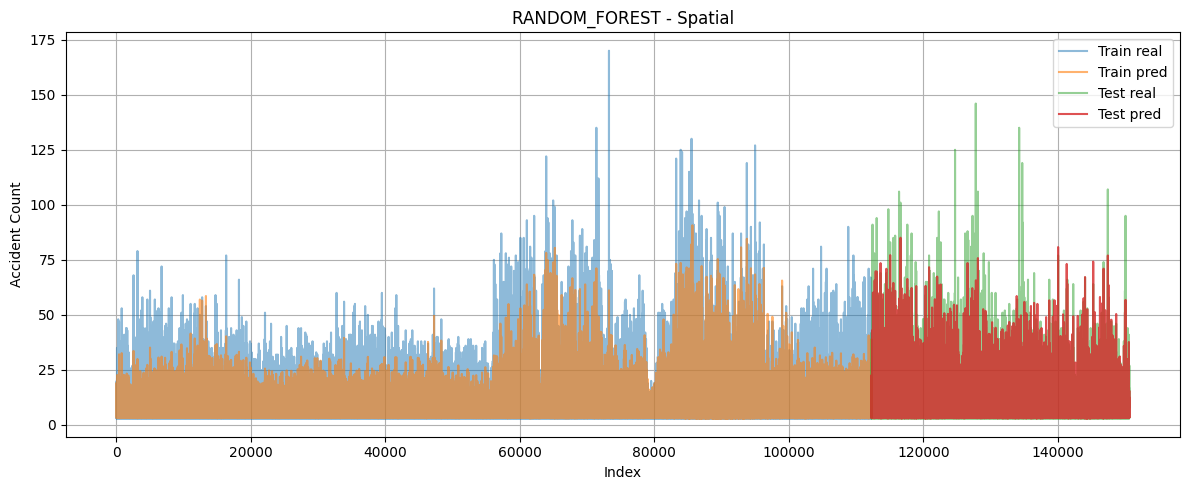

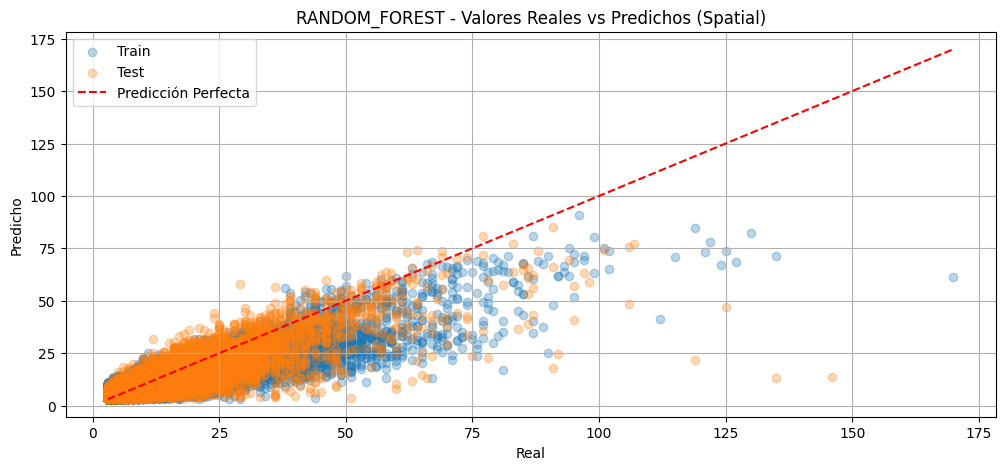

<Figure size 1200x400 with 0 Axes>

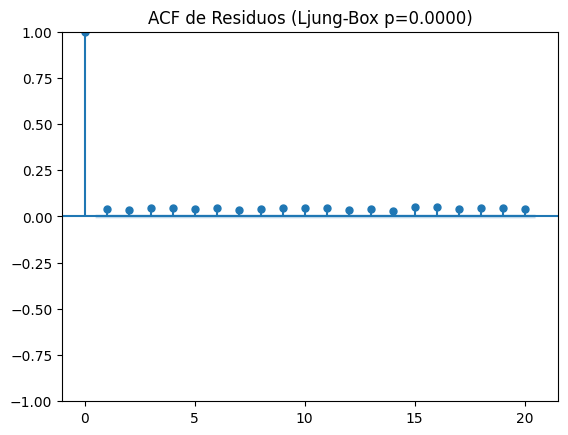

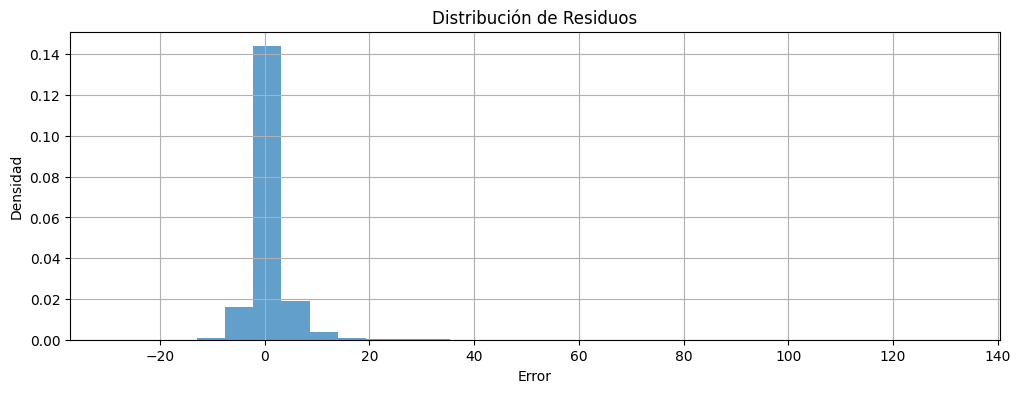


Optimizando XGBOOST


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(
c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:28:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Error en LIME: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

→ Validación: SPATIAL
  - Mejores parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  - Train RMSE: 3.72, MAE: 2.34, R2: 0.77
  - Test  RMSE: 3.84, MAE: 2.12, R2: 0.77


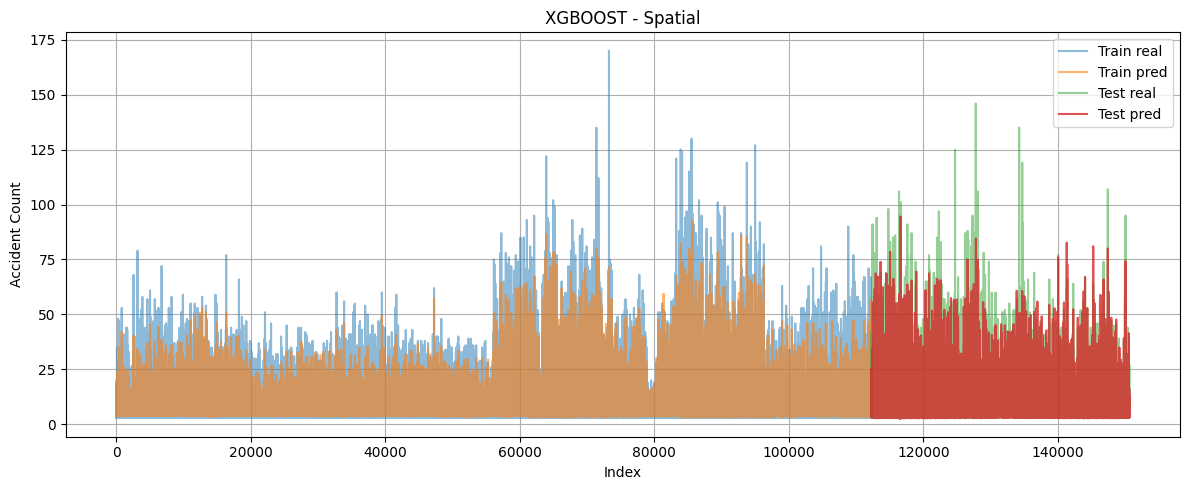

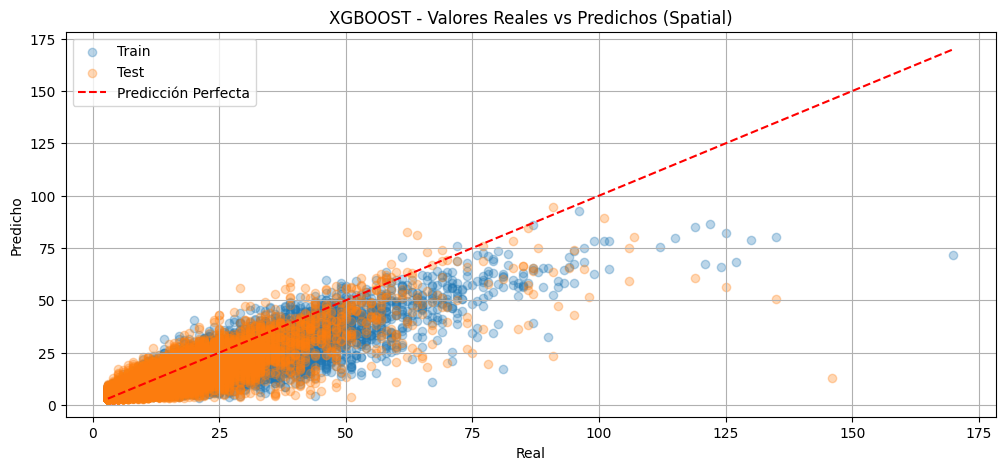

<Figure size 1200x400 with 0 Axes>

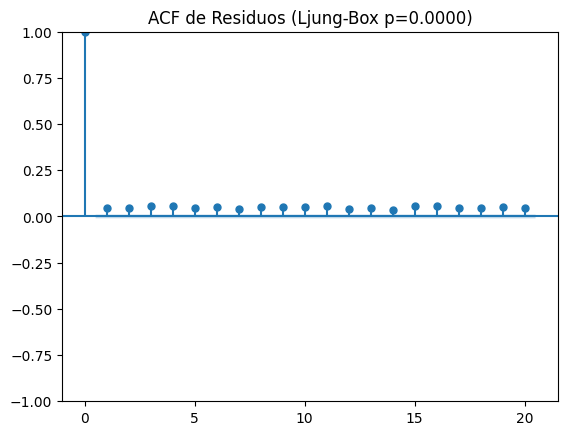

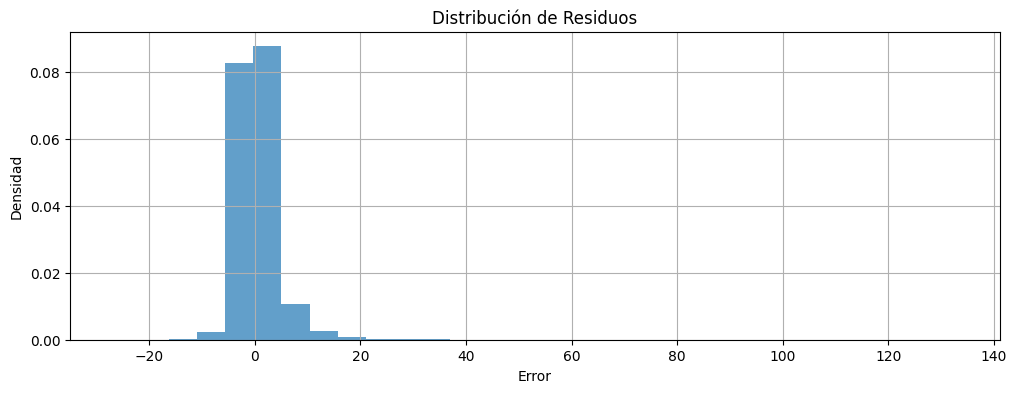


Optimizando SVR_LINEAR


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {'model__C': 1.0}
  - Train RMSE: 3.80, MAE: 2.30, R2: 0.79
  - Test  RMSE: 4.22, MAE: 2.42, R2: 0.72


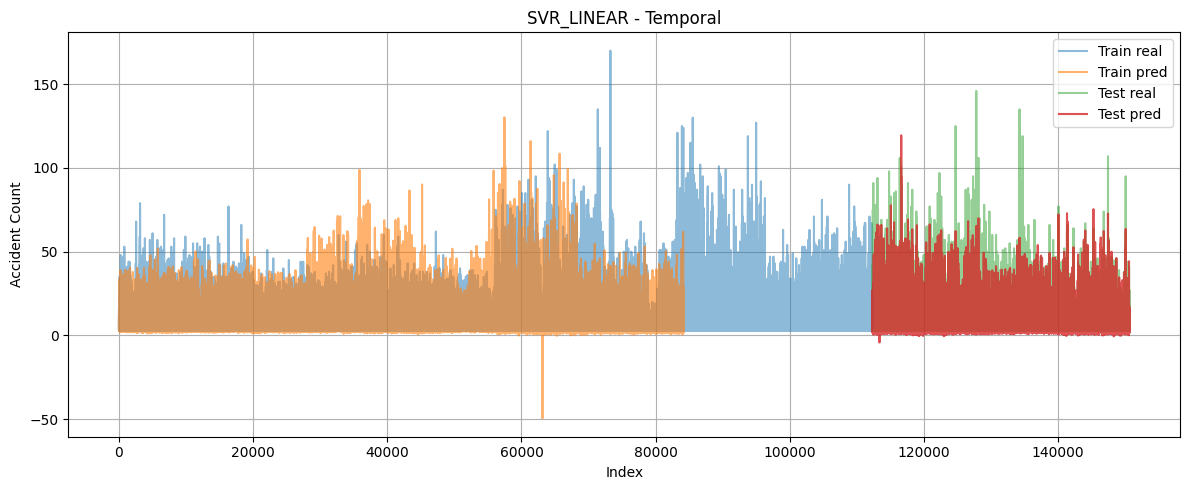

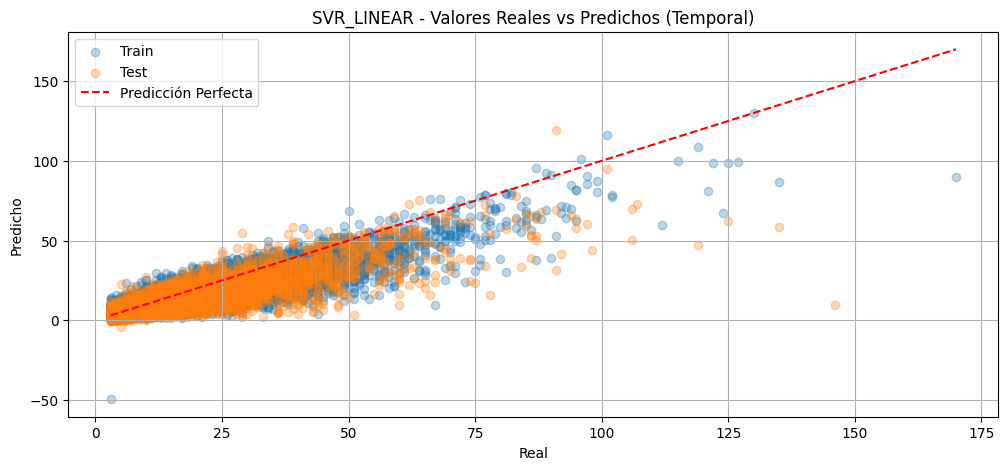

<Figure size 1200x400 with 0 Axes>

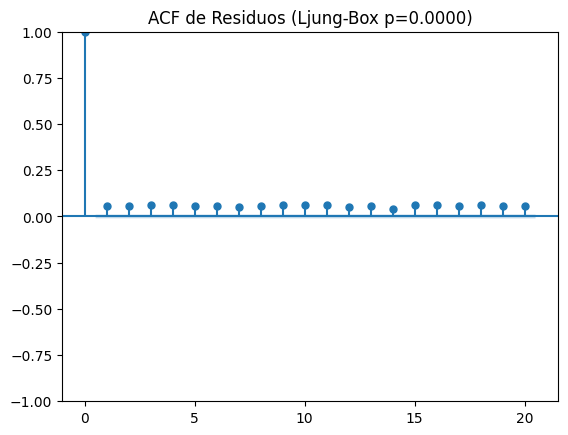

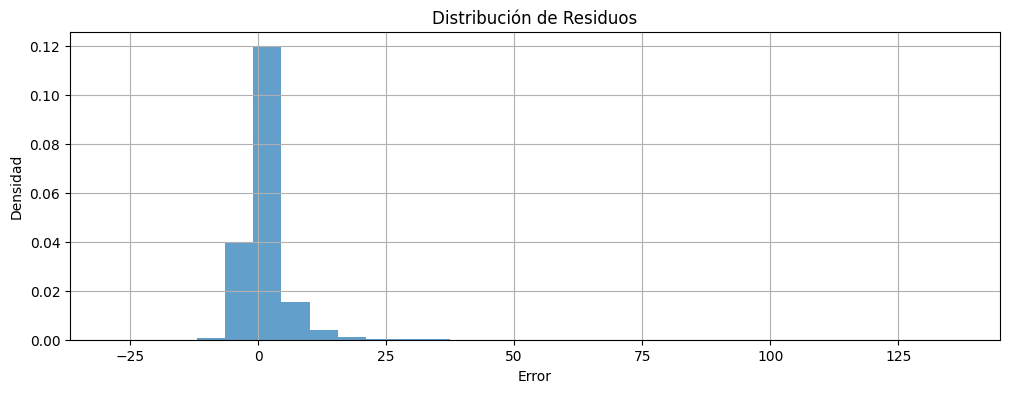

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {'model__C': 1.0}
  - Train RMSE: 3.97, MAE: 2.51, R2: 0.74
  - Test  RMSE: 4.23, MAE: 2.42, R2: 0.72


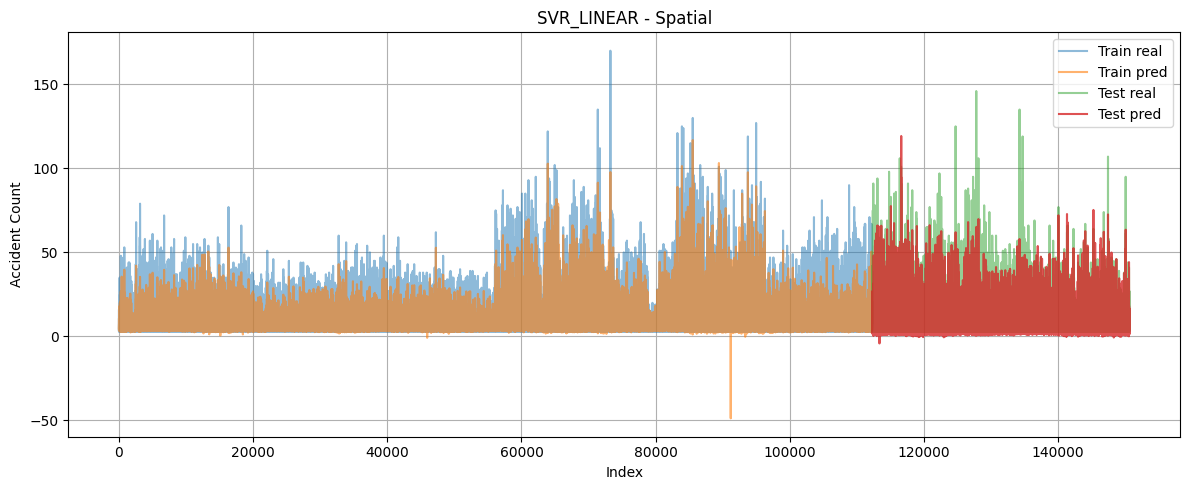

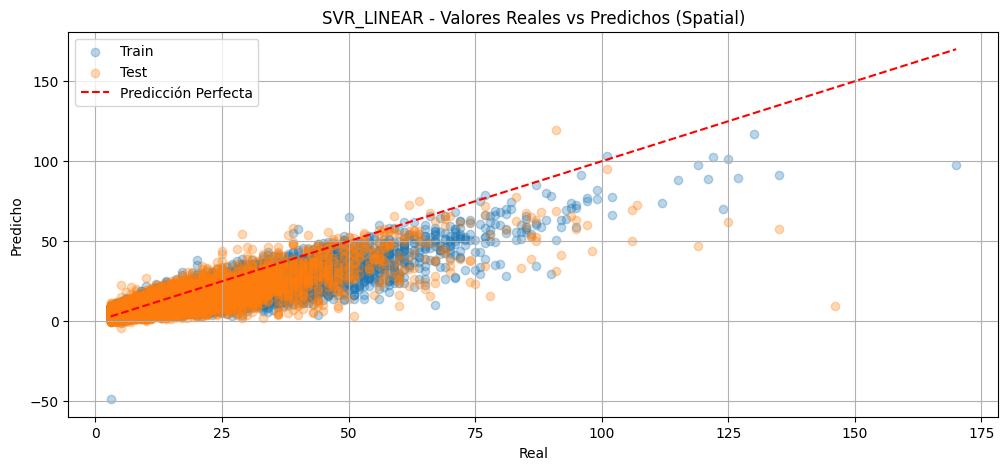

<Figure size 1200x400 with 0 Axes>

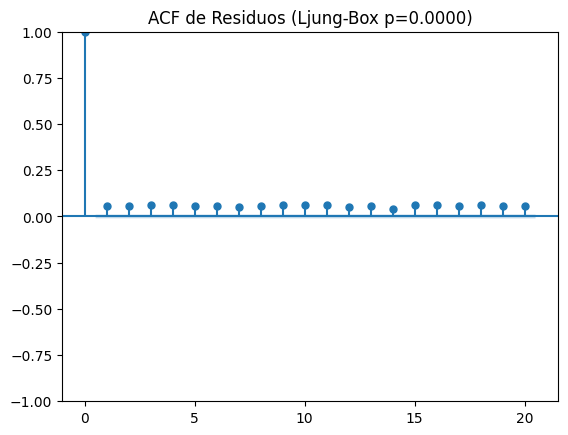

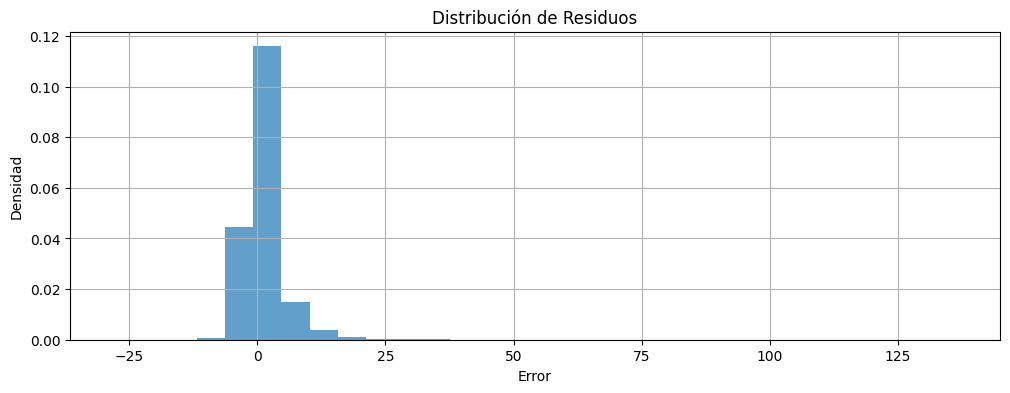


Optimizando SVR_RBF


c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: TEMPORAL
  - Mejores parámetros: {}
  - Train RMSE: 8.00, MAE: 4.87, R2: 0.07
  - Test  RMSE: 7.61, MAE: 4.93, R2: 0.10


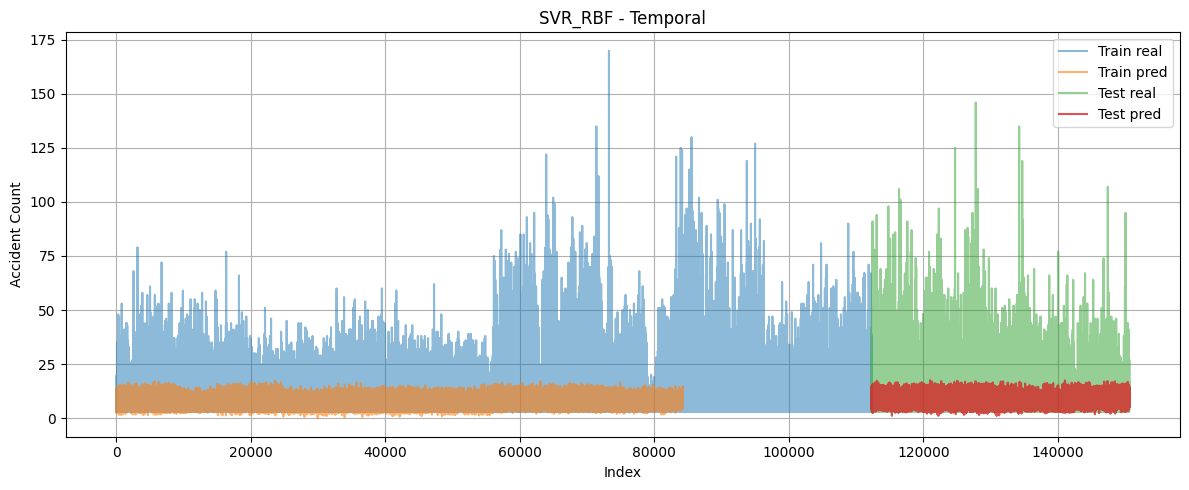

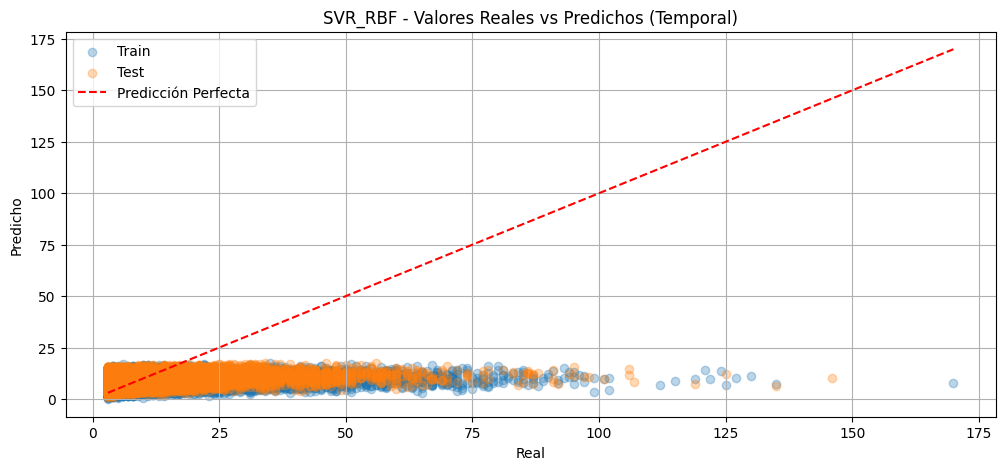

<Figure size 1200x400 with 0 Axes>

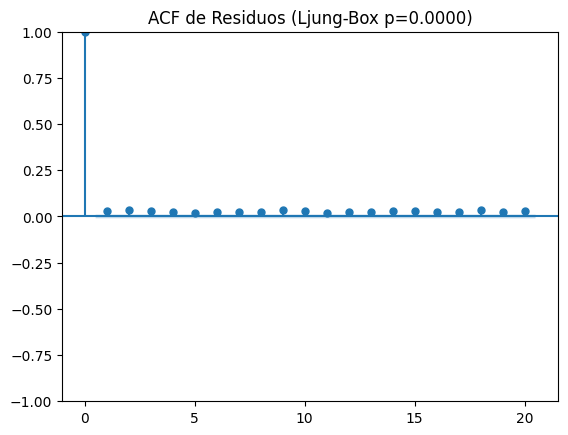

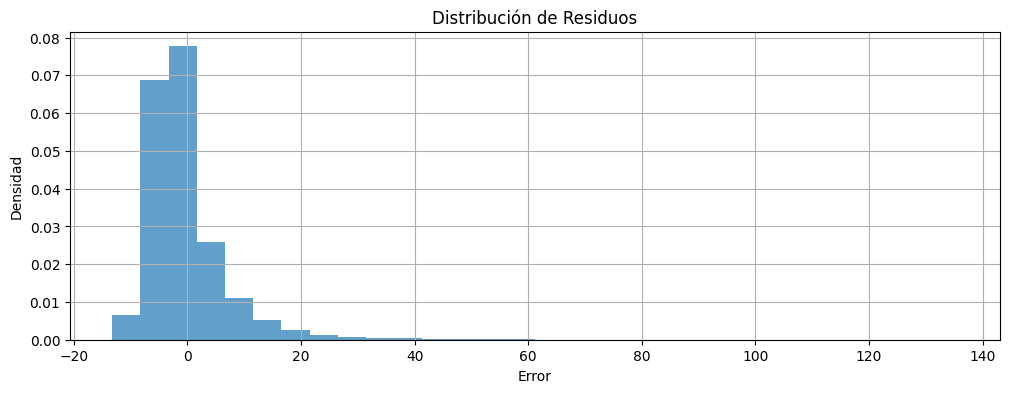

c:\Users\Sara\AppData\Local\Programs\python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan]
  warnings.warn(



→ Validación: SPATIAL
  - Mejores parámetros: {}
  - Train RMSE: 7.97, MAE: 5.06, R2: -0.05
  - Test  RMSE: 7.60, MAE: 4.86, R2: 0.10


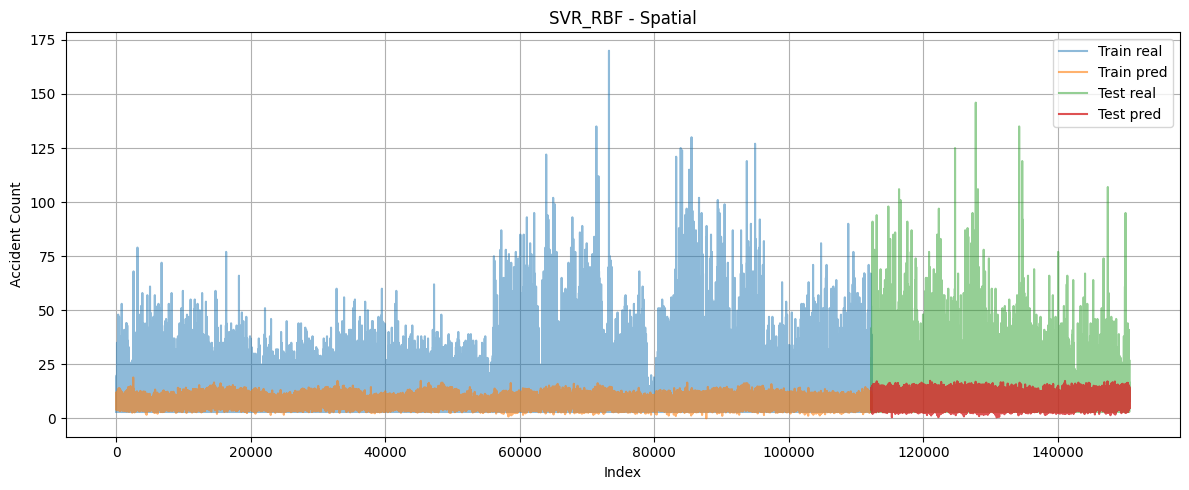

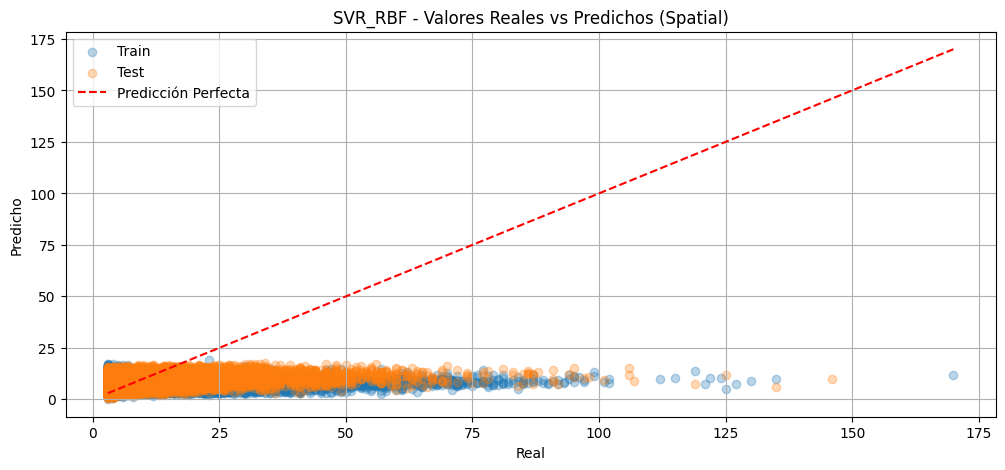

<Figure size 1200x400 with 0 Axes>

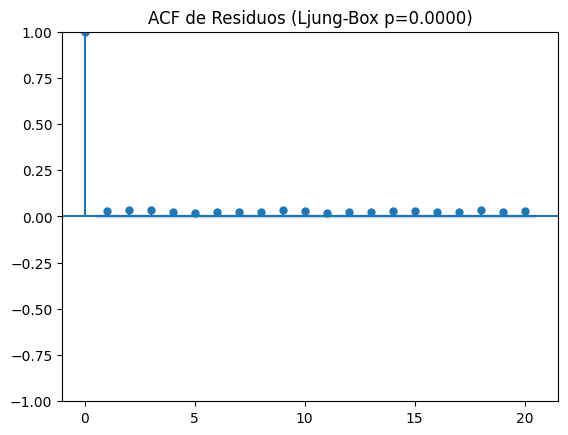

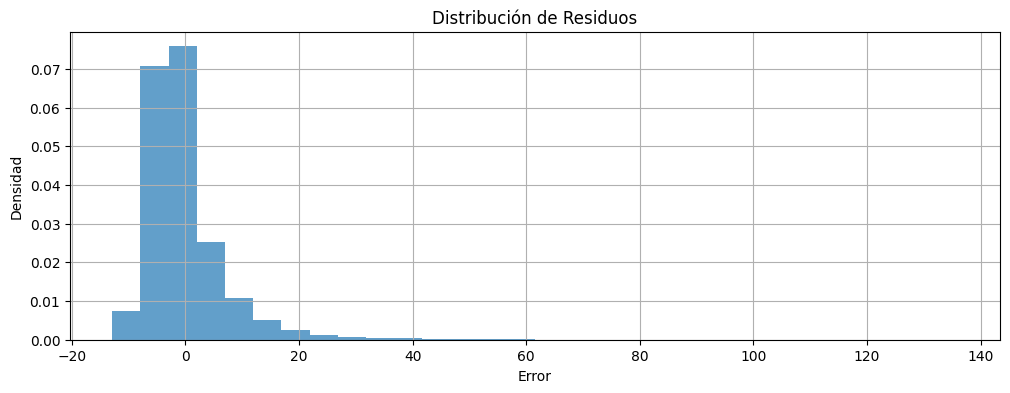

In [13]:
for model_name in pipelines:
    if model_name not in param_grids:
        continue

    print(f"\n{'='*40}\nOptimizando {model_name.upper()}\n{'='*40}")
    
    for mode, cv, group in [('temporal', tscv, None), ('spatial', group_kfold, groups_train)]:
        start = time.time()

        search = GridSearchCV(
            pipelines[model_name],
            param_grids[model_name],
            cv=cv,
            scoring=scorer,
            n_jobs=-1,
            verbose=0
        )

        # Añadir early stopping para XGBoost si temporal
        if model_name == 'xgboost' and mode == 'temporal':
            continue
        else:
            if mode == 'spatial':
                search.fit(X_train, y_train, groups=group)
            else:
                search.fit(X_train, y_train)


        best_model = search.best_estimator_
        best_params = search.best_params_

        # Predicción en test
        y_pred_test = best_model.predict(X_test)

        # Predicción en train (implementación manual para temporal)
        if mode == 'spatial':
            y_pred_train = cross_val_predict(best_model, X_train, y_train, cv=group_kfold, groups=groups_train, n_jobs=-1)
        else:
            y_pred_train = np.full(y_train.shape[0], np.nan)
            for train_idx, test_idx in tscv.split(X_train):
                best_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
                y_pred_train[test_idx] = best_model.predict(X_train.iloc[test_idx])
            # Eliminar NaN de splits no cubiertos
            mask = ~np.isnan(y_pred_train)
            y_pred_train = y_pred_train[mask]
            y_train_filtered = y_train[mask]
        
      # ================== IMPLEMENTACIÓN DE LIME ==================
        if model_name in ['random_forest', 'xgboost']:  # Solo para modelos de árboles
            try:
                # Preprocesar datos para LIME
                X_train_processed = preprocessor.transform(X_train)
                explainer = lime.lime_tabular.LimeTabularExplainer(
                    training_data=X_train_processed,
                    feature_names=preprocessor.get_feature_names_out(),
                    mode="regression",
                    verbose=False
                )

                # Explicar una instancia de prueba
                instance_idx = 0
                instance_processed = preprocessor.transform(X_test.iloc[[instance_idx]])
                exp = explainer.explain_instance(
                    instance_processed[0], 
                    best_model.named_steps['model'].predict,
                    num_features=5
                )

                # Mostrar explicación
                print(f"\nExplicación LIME para {model_name.upper()} (Instancia {instance_idx}):")
                
                try:
                    from IPython.display import display, HTML
                    display(HTML(exp.as_html()))
                except:
                    for feature, weight in exp.as_list():
                        print(f"{feature}: {weight:.4f}")

            except Exception as e:
                print(f"Error en LIME: {str(e)}")
        # ============================================================


        duration = round(time.time() - start, 2)
        
        # Métricas
        rmse_test = root_mean_squared_error(y_test, y_pred_test)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)

        if mode == 'spatial':
            rmse_train = root_mean_squared_error(y_train, y_pred_train)
            mae_train = mean_absolute_error(y_train, y_pred_train)
            r2_train = r2_score(y_train, y_pred_train)
        else:
            rmse_train = root_mean_squared_error(y_train_filtered, y_pred_train)
            mae_train = mean_absolute_error(y_train_filtered, y_pred_train)
            r2_train = r2_score(y_train_filtered, y_pred_train)

        # Pruebas estadísticas
        residuals = y_test - y_pred_test
        ljung_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
        jb_p = jarque_bera(residuals)[1]

        print(f"\n→ Validación: {mode.upper()}")
        print(f"  - Mejores parámetros: {best_params}")
        print(f"  - Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
        print(f"  - Test  RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

        results.append({
            'Model': model_name.upper(),
            'Type': mode.capitalize(),
            'Train_RMSE': round(rmse_train, 2),
            'Train_MAE': round(mae_train, 2),
            'Train_R2': round(r2_train, 2),
            'Test_RMSE': round(rmse_test, 2),
            'Test_MAE': round(mae_test, 2),
            'Test_R2': round(r2_test, 2),
            'Duration (s)': duration,
            'Ljung-Box p-value': round(ljung_p, 4),
            'Jarque-Bera p-value': round(jb_p, 4)
        })

        # Gráfica
        plt.figure(figsize=(12, 5))
        plt.plot(y_train.values, label='Train real', alpha=0.5)
        plt.plot(y_pred_train, label='Train pred', alpha=0.6)
        plt.plot(np.arange(len(y_train), len(y_train)+len(y_test)), y_test.values, label='Test real', alpha=0.5)
        plt.plot(np.arange(len(y_train), len(y_train)+len(y_test)), y_pred_test, label='Test pred', alpha=0.8)
        plt.title(f'{model_name.upper()} - {mode.capitalize()}')
        plt.xlabel('Index')
        plt.ylabel('Accident Count')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # ================== NUEVAS VISUALIZACIONES ==================
        # 1. Gráfico de valores reales vs predichos
        plt.figure(figsize=(12, 5))
        
        # Definir datos según el modo de validación
        if mode == 'temporal':
            y_train_plot = y_train_filtered
            y_pred_train_plot = y_pred_train
        else:  # spatial
            y_train_plot = y_train
            y_pred_train_plot = y_pred_train
        
        # Scatter plot para train y test
        plt.scatter(y_train_plot, y_pred_train_plot, alpha=0.3, label='Train')
        plt.scatter(y_test, y_pred_test, alpha=0.3, label='Test')
        
        # Línea de referencia perfecta
        min_val = min(np.min(y_train_plot), np.min(y_test))
        max_val = max(np.max(y_train_plot), np.max(y_test))
        plt.plot([min_val, max_val], [min_val, max_val], '--r', label='Predicción Perfecta')
        
        plt.title(f'{model_name.upper()} - Valores Reales vs Predichos ({mode.capitalize()})')
        plt.xlabel('Real')
        plt.ylabel('Predicho')
        plt.legend()
        plt.grid(True)
        plt.show()
        # 2. ACF de residuos con p-value
        plt.figure(figsize=(12, 4))
        plot_acf(residuals, lags=20, alpha=0.05)
        plt.title(f'ACF de Residuos (Ljung-Box p={ljung_p:.4f})')
        plt.show()

        # 3. Histograma de residuos
        plt.figure(figsize=(12, 4))
        plt.hist(residuals, bins=30, density=True, alpha=0.7)
        plt.title('Distribución de Residuos')
        plt.xlabel('Error')
        plt.ylabel('Densidad')
        plt.grid(True)
        plt.show()

In [14]:
results_df = pd.DataFrame(results)
print("\n\nRESULTADOS FINALES:")
print(results_df)



RESULTADOS FINALES:
            Model      Type  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  \
0             KNN  Temporal        6.53       3.80      0.38       6.10   
1             KNN   Spatial        7.63       4.63      0.04       6.06   
2           RIDGE  Temporal        3.93       2.40      0.77       4.10   
3           RIDGE   Spatial        4.07       2.68      0.73       4.10   
4           LASSO  Temporal        6.50       3.69      0.38       5.19   
5           LASSO   Spatial        6.80       4.21      0.24       5.19   
6   RANDOM_FOREST  Temporal        3.78       2.17      0.79       3.90   
7   RANDOM_FOREST   Spatial        3.99       2.37      0.74       3.90   
8         XGBOOST   Spatial        3.72       2.34      0.77       3.84   
9      SVR_LINEAR  Temporal        3.80       2.30      0.79       4.22   
10     SVR_LINEAR   Spatial        3.97       2.51      0.74       4.23   
11        SVR_RBF  Temporal        8.00       4.87      0.07       7.61   
12 

In [15]:
print(results_df.iloc[[6]].to_string(index=False))

        Model     Type  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  Test_MAE  Test_R2  Duration (s)  Ljung-Box p-value  Jarque-Bera p-value
RANDOM_FOREST Temporal        3.78       2.17      0.79        3.9      2.08     0.76        314.76                0.0                  0.0


In [16]:
print(results_df.iloc[[7]].to_string(index=False))

        Model    Type  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  Test_MAE  Test_R2  Duration (s)  Ljung-Box p-value  Jarque-Bera p-value
RANDOM_FOREST Spatial        3.99       2.37      0.74        3.9      2.08     0.76        270.44                0.0                  0.0


In [17]:
print(results_df.iloc[[8]].to_string(index=False))

  Model    Type  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  Test_MAE  Test_R2  Duration (s)  Ljung-Box p-value  Jarque-Bera p-value
XGBOOST Spatial        3.72       2.34      0.77       3.84      2.12     0.77           3.9                0.0                  0.0
